<div style="text-align: center;">

# Sustainability Aware Asset Management  
# Portfolio Allocation with a Carbon Objective  

<br>

**Course:** Sustainability Aware Asset Management<br>
**Instructor:** Professor Eric Jondeau<br> 
**Academic Year:** 2025–2026<br>  

<br>

**Group Members**  
Matteo Piras<br>
Tomas Papuga<br> 
Marco d'Amico<br>
Roberto Berardi<br> 

<br>

**Submission Date:** May 2026  

</div>

# Part I - Standard Portfolio Allocation
## 1) Data Cleaning

### 1.1) Missing Prices and Datastream Error Rows

The raw datasets are direct exports from Datastream and may contain structural inconsistencies that must be addressed before any financial analysis.

Some ISIN codes are flagged with `$$ER`, indicating that Datastream could not correctly match the requested security (for example, due to share class mismatches or unavailable data). These rows do not contain valid financial information and are therefore removed from all datasets.

We then standardize the structure of each file by:
- Converting ISIN codes to a consistent string format,
- Removing non-numeric columns such as firm names,
- Transposing the data so that dates form the index and firms form the columns,
- Converting all values to numeric format.

At this stage, we only correct structural and data-quality issues. No economic filtering (region, carbon availability, liquidity, etc.) is applied yet. 

In [41]:
import pandas as pd
import numpy as np

print("Starting finalized data preparation process...")

# --------------------------------------------------------
# 1. Setup and Static Data Filtering
# --------------------------------------------------------
# Load the static dataset to identify the initial investment universe
static_df = pd.read_excel('Data_2026/Static_2025.xlsx')
static_df['ISIN'] = static_df['ISIN'].astype(str).str.strip()

# Isolate firms belonging to the Emerging Markets (EM) region
em_firms = static_df[static_df['Region'] == 'EM'].copy()
valid_em_isins = em_firms['ISIN'].unique().tolist()

def load_and_transpose(filepath, is_monthly=False):
    """
    Standardizes Datastream Excel exports into time-series DataFrames.
    Removes error flags ($$ER) and transposes firms to columns.
    """
    df = pd.read_excel(filepath)
    # Rule: Explicitly delete ISINs with Datastream errors ($$ER)
    df = df[~df['ISIN'].astype(str).str.contains(r'\$\$ER', na=False)]
    df['ISIN'] = df['ISIN'].astype(str).str.strip()
    df.set_index('ISIN', inplace=True)
    
    if 'NAME' in df.columns:
        df.drop(columns=['NAME'], inplace=True)
    
    df_t = df.T
    df_t = df_t.apply(pd.to_numeric, errors='coerce')
    
    # Handle indexing based on data frequency (Monthly for RI, Yearly for Carbon)
    if is_monthly:
        df_t.index = pd.to_datetime(df_t.index)
    else:
        df_t.index = df_t.index.astype(int)
    return df_t

print("Static data loaded and EM firms identified.")

Starting finalized data preparation process...
Static data loaded and EM firms identified.


### 1.2) Missing Values: Beginning, Middle, and End of Sample

The datasets contain different types of missing observations that must be handled carefully to ensure consistent return estimation and avoid distortions in portfolio construction.

First, missing values at the beginning of the sample typically correspond to firms that were not yet listed or had not started reporting data. In this case, no correction is applied.

Second, missing values between two available observations usually reflect temporary reporting gaps or data issues. To preserve continuity in the return series, we apply a forward-fill procedure to bridge these internal gaps.

Third, missing values at the end of the sample generally correspond to firm delisting or default events. In such cases, the price is assumed to drop to zero, implying a realized return of −100% in the month following the last valid observation. All subsequent periods are set to missing values to avoid artificially lowering volatility.

This treatment ensures a realistic handling of firm exits while maintaining the integrity of the historical return series.

In [42]:
# --------------------------------------------------------
# 2. Return Index (RI) Processing with Delisting Logic
# --------------------------------------------------------
ri_monthly = load_and_transpose('Data_2026/DS_RI_T_USD_M_2025.xlsx', is_monthly=True)
ri_em = ri_monthly[[isin for isin in valid_em_isins if isin in ri_monthly.columns]].copy()

# Rule: Treat prices < 0.5 as missing values to avoid extreme returns from penny stocks
ri_em[ri_em < 0.5] = np.nan

# CRITICAL: Identify the real last valid date BEFORE filling gaps.
# This ensures that delisting (final disappearance) is not masked by forward-filling.
real_last_valid_dates = ri_em.apply(lambda col: col.last_valid_index())

# Rule: Fill gaps between available values (Forward Fill) to bridge misreporting
ri_em_filled = ri_em.ffill()
returns_em = ri_em_filled.pct_change(fill_method=None)

# Applying Precise Delisting Logic: -100% loss followed by NaNs
for isin in returns_em.columns:
    last_date = real_last_valid_dates[isin]
    if pd.notna(last_date):
        last_pos = returns_em.index.get_loc(last_date)
        
        # If the firm disappears before the end of the sample, acknowledge the loss
        if last_pos < len(returns_em) - 1:
            # Force -100% return in the month following the last valid price
            returns_em.iloc[last_pos + 1, returns_em.columns.get_loc(isin)] = -1.0
            
            # Ensure post-delisting periods are NaN (not zero) to avoid stale price/low volatility bias
            if last_pos + 1 < len(returns_em) - 1:
                returns_em.iloc[last_pos + 2:, returns_em.columns.get_loc(isin)] = np.nan
    else:
        # Mark firms with no valid data for complete removal
        returns_em[isin] = np.nan

### 1.3) Carbon Data Preparation and Validation

Scope 1 and Scope 2 carbon emissions data are first loaded from the Datastream files and transformed into annual time-series format. The sample is then restricted to firms belonging to the Emerging Markets universe.

To account for reporting gaps across years, carbon emissions data are forward-filled. This means that when a firm does not report emissions in a given year, the most recent available observation is carried forward.

After this step, firms with no available data at all are removed from the corresponding datasets. The same cleaning rule is also applied to the returns matrix, so that firms without usable information are excluded from the analysis.

Finally, a validation summary is printed to check the dimensions of the returns, Scope 1, and Scope 2 datasets before proceeding with the next steps.

In [43]:

scope1_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_1_Y_2025.xlsx', is_monthly=False)
scope2_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_2_Y_2025.xlsx', is_monthly=False)

# Filter for EM and apply Forward Fill for reporting gaps between years
scope1_em = scope1_em[[isin for isin in valid_em_isins if isin in scope1_em.columns]].copy().ffill()
scope2_em = scope2_em[[isin for isin in valid_em_isins if isin in scope2_em.columns]].copy().ffill()

# Rule: Physically delete firms with no associated data from all tables
returns_em.dropna(how='all', axis=1, inplace=True)
scope1_em.dropna(how='all', axis=1, inplace=True)
scope2_em.dropna(how='all', axis=1, inplace=True)

print("Data Validation Overview:")
print(f"- Returns Matrix: {returns_em.shape[0]} months, {returns_em.shape[1]} firms")
print(f"- Scope 1/2 Matrices: {scope1_em.shape[0]} years")
display(returns_em.head())

Data Validation Overview:
- Returns Matrix: 314 months, 668 firms
- Scope 1/2 Matrices: 27 years


ISIN,ARALUA010258,ARP125991090,ARSIDE010029,BMG211591018,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4,...,ZAE000117321,ZAE000127148,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-31,0.176511,-0.051861,-0.004877,NaN,-0.044175,-0.067245,0.023986,-0.249634,0.011906,NaN,...,-0.115161,-0.049527,0.096965,0.067794,0.205596,0.099568,-0.080722,0.125341,0.021174,-0.114179
2000-02-29,0.050002,0.178923,0.039543,NaN,-0.045539,-0.036328,-0.107794,0.005452,0.043492,NaN,...,-0.037800,-0.100608,-0.326248,0.028928,-0.053481,-0.084315,-0.062844,-0.181598,0.018379,-0.023150
2000-03-31,-0.023552,-0.105072,-0.002113,NaN,0.313941,-0.130625,0.152061,0.014002,0.002361,NaN,...,-0.067887,-0.034040,-0.044066,-0.176088,-0.126866,0.073915,-0.054382,-0.038462,-0.142989,-0.104274
2000-04-28,-0.016173,-0.161842,-0.071188,NaN,-0.001350,-0.077311,-0.108617,-0.032966,-0.020143,NaN,...,-0.034586,-0.042240,-0.172342,-0.129131,-0.035409,-0.208833,-0.030503,-0.224615,-0.095572,0.003496


### 1.4) Dynamic Investment Set Construction (10-Year Rolling Window)

After cleaning the data, we construct the investment universe dynamically for each portfolio formation year.

For each year 
𝑌
Y, we use a 10-year rolling estimation window (from January 
𝑌
−
9
Y−9 to December 
𝑌
Y) to determine firm eligibility. The portfolio formed at the end of year 
𝑌
Y is implemented during year 
𝑌
+
1
Y+1.

A firm is included in the investment set only if it satisfies all of the following conditions:

Price availability at formation date:
The firm must have a valid price at the end of year 
𝑌
Y. Firms with missing or invalid prices at the portfolio formation date are excluded.

Liquidity condition (stale price filter):
Over the 10-year estimation window, the proportion of zero monthly returns must not exceed 50%. This ensures that illiquid firms do not artificially reduce estimated portfolio volatility.

Carbon data availability:
Both Scope 1 and Scope 2 emissions data must be available at the end of year 
𝑌
Y. This guarantees consistency between the financial allocation and the sustainability analysis.

The resulting set of eligible firms is stored for each holding year 
𝑌
+
1
Y+1, forming a sequence of dynamically updated investment universes.

In [44]:
print("Initiating dynamic filtering for 10-year rolling windows...")

# Step 5: Dynamic Universe Construction
# We identify eligible firms for each year based on historical liquidity and ESG disclosure.
valid_investment_sets = {}
estimation_years = range(2009, 2025)

for Y in estimation_years:
    # Define the 10-year rolling estimation window (Dec Y-9 to Dec Y)
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"
    window_returns = returns_em.loc[start_date:end_date]
    window_prices = ri_em.loc[start_date:end_date]
    
    valid_isins_for_year = []
    
    for isin in returns_em.columns:
        # Rule: Price Availability at end of year Y
        # Exclude firms missing a valid price (>0.5 USD) at the portfolio formation date.
        if pd.isna(window_prices[isin].iloc[-1]):
            continue
            
        # Rule: Stale Price / Liquidity Filter
        # Calculate the ratio of months with zero returns to avoid illiquid assets.
        total_valid_months = window_returns[isin].notna().sum()
        if total_valid_months < 36:
            continue
        
        # Exclude if the firm has no price movement for > 50% of the window.
        if (window_returns[isin] == 0.0).sum() / 120 > 0.5:
            continue
            
        # Rule: Carbon Data Availability for Year Y
        # Both Scope 1 and Scope 2 data must be present for the firm to be eligible.
        if Y in scope1_em.index and Y in scope2_em.index:
            if isin in scope1_em.columns and isin in scope2_em.columns:
                if not pd.isna(scope1_em.loc[Y, isin]) and not pd.isna(scope2_em.loc[Y, isin]):
                    valid_isins_for_year.append(isin)
    
    # Store the investment set for the subsequent holding period (Y + 1)
    valid_investment_sets[Y + 1] = valid_isins_for_year
    print(f"Holding Year {Y+1}: {len(valid_isins_for_year)} firms identified.")

print("\nInvestment universes constructed successfully.")

Initiating dynamic filtering for 10-year rolling windows...
Holding Year 2010: 66 firms identified.
Holding Year 2011: 161 firms identified.
Holding Year 2012: 198 firms identified.
Holding Year 2013: 224 firms identified.
Holding Year 2014: 245 firms identified.
Holding Year 2015: 267 firms identified.
Holding Year 2016: 297 firms identified.
Holding Year 2017: 334 firms identified.
Holding Year 2018: 381 firms identified.
Holding Year 2019: 416 firms identified.
Holding Year 2020: 463 firms identified.
Holding Year 2021: 504 firms identified.
Holding Year 2022: 542 firms identified.
Holding Year 2023: 571 firms identified.
Holding Year 2024: 579 firms identified.
Holding Year 2025: 566 firms identified.

Investment universes constructed successfully.


# 2) Minimum-Variance Portfolio Allocation
### 2.1) Investment set: Estimation of Expected Returns and Covariance Matrices

In this section, we compute the return moments required for the portfolio optimization. For each portfolio formed at the end of year $Y$, we extract a 10-year rolling window of monthly returns (from January $Y-9$ to December $Y$) for the eligible investment set.

To strictly adhere to the provided mathematical framework, the calculations are implemented exactly as defined by the formulas:

- Missing Data Treatment: All missing returns within the estimation window are explicitly replaced by 0 before any computation. This ensures that the number of monthly observations ($\tau$) remains exactly 120 for all firms, avoiding the need to drop incomplete rows.
- Expected Returns: Calculated as the sum of returns over the window divided by the number of observations, perfectly mirroring the formula $\hat{\mu}_Y = \frac{1}{\tau} \sum R_{t-k}$.
- Covariance Matrix: Estimated using the exact population formula $\Sigma_Y = \frac{1}{\tau} \sum (R_{t-k} - \hat{\mu}_Y)'(R_{t-k} - \hat{\mu}_Y)$. To guarantee numerical precision, this is implemented using pure linear algebra operations, specifically the dot product of the centered return arrays divided by $\tau$.

The resulting expected returns and covariance matrices are stored in dictionaries and serve as the direct inputs for the subsequent minimum variance optimization.

In [45]:
print("Calculating Expected Returns and Covariance Matrices...")

# --------------------------------------------------------
# 6. Estimation of Expected Returns and Covariance Matrices
# --------------------------------------------------------
# Using the formulas exactly:
#
# mu_hat_Y = (1/tau) * sum R_t
#
# Sigma_Y = (1/tau) * sum (R_t - mu_hat_Y)'(R_t - mu_hat_Y)
#
# Missing values are replaced by 0 before computation.

mu_estimates = {}
sigma_estimates = {}

estimation_years = range(2013, 2025)

for Y in estimation_years:

    holding_year = Y + 1
    valid_isins = valid_investment_sets[holding_year]

    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # 10-year estimation window
    start_date, end_date = f"{Y-9}-01-01", f"{Y}-12-31"

    window_returns = returns_em.loc[start_date:end_date, valid_isins].copy()

    # Replace missing returns with 0
    window_returns = window_returns.fillna(0)

    # number of observations (should be 120 months)
    tau = window_returns.shape[0]

    # --------------------------------------------------------
    # Expected Returns (formula)
    # --------------------------------------------------------
    mu_hat_Y = window_returns.sum(axis=0) / tau

    # --------------------------------------------------------
    # Covariance Matrix (formula)
    # --------------------------------------------------------
    R = window_returns.to_numpy()            # tau x N
    mu = mu_hat_Y.to_numpy().reshape(1, -1)  # 1 x N

    # center returns
    R_centered = R - mu

    # covariance formula
    Sigma_array = (R_centered.T @ R_centered) / tau

    # convert back to dataframe
    Sigma_Y = pd.DataFrame(
        Sigma_array,
        index=window_returns.columns,
        columns=window_returns.columns
    )

    mu_estimates[holding_year] = mu_hat_Y
    sigma_estimates[holding_year] = Sigma_Y

    print(
        f"Holding Year {holding_year}: "
        f"{len(valid_isins)} firms, "
        f"tau={tau}, "
        f"mu size={mu_hat_Y.shape[0]}, "
        f"Sigma shape={Sigma_Y.shape}"
    )

print("\nExpected returns and covariance matrices computed successfully.")

# --------------------------------------------------------
# Example check
# --------------------------------------------------------
example_year = 2014
if example_year in mu_estimates and example_year in sigma_estimates:
    print(f"\nExample: Holding Year {example_year}")
    display(mu_estimates[example_year].head())
    display(sigma_estimates[example_year].iloc[:5, :5])

Calculating Expected Returns and Covariance Matrices...
Holding Year 2014: 245 firms, tau=120, mu size=245, Sigma shape=(245, 245)
Holding Year 2015: 267 firms, tau=120, mu size=267, Sigma shape=(267, 267)
Holding Year 2016: 297 firms, tau=120, mu size=297, Sigma shape=(297, 297)
Holding Year 2017: 334 firms, tau=120, mu size=334, Sigma shape=(334, 334)
Holding Year 2018: 381 firms, tau=120, mu size=381, Sigma shape=(381, 381)
Holding Year 2019: 416 firms, tau=120, mu size=416, Sigma shape=(416, 416)
Holding Year 2020: 463 firms, tau=120, mu size=463, Sigma shape=(463, 463)
Holding Year 2021: 504 firms, tau=120, mu size=504, Sigma shape=(504, 504)
Holding Year 2022: 542 firms, tau=120, mu size=542, Sigma shape=(542, 542)
Holding Year 2023: 571 firms, tau=120, mu size=571, Sigma shape=(571, 571)
Holding Year 2024: 579 firms, tau=120, mu size=579, Sigma shape=(579, 579)
Holding Year 2025: 566 firms, tau=120, mu size=566, Sigma shape=(566, 566)

Expected returns and covariance matrices co

ISIN
BRBBASACNOR3    0.024255
BRBBDCACNPR8    0.022722
BRBRFSACNOR8    0.032435
BRBRKMACNPA4    0.015174
BRCESPACNPB4    0.011178
dtype: float64

ISIN,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4
ISIN,,,,,
BRBBASACNOR3,0.015590,0.010866,0.008129,0.007731,0.006893
BRBBDCACNPR8,0.010866,0.012099,0.008446,0.007131,0.005413
BRBRFSACNOR8,0.008129,0.008446,0.014663,0.006491,0.005183
BRBRKMACNPA4,0.007731,0.007131,0.006491,0.019695,0.004748
BRCESPACNPB4,0.006893,0.005413,0.005183,0.004748,0.014449


### 2.2) Minimum Variance Portfolio (Out-of-Sample)

We construct a **long-only minimum variance portfolio** using an out-of-sample framework.  
At the end of each year \(Y\), the portfolio weights \(\alpha_Y\) are computed using the covariance matrix \(\Sigma_Y\) estimated from the previous 10 years of monthly returns.

The optimal weights are obtained by solving the following optimization problem:

$$
\min_{\alpha_Y} \sigma_{p,Y}^2 = \alpha_Y' \Sigma_Y \alpha_Y
$$

subject to

$$
\alpha_Y' e = 1, \qquad \alpha_{i,Y} \ge 0
$$

where \(e = (1,\ldots,1)'\). This ensures that portfolio weights sum to one and remain non-negative.

The portfolio is **rebalanced annually** from December 2013 to December 2024. The weights determined at the end of year \(Y\) are applied during the following year \(Y+1\).

### Ex-Post Portfolio Returns

Monthly portfolio returns are computed during the holding year as

$$
R_{p,t+k} = \alpha'_{t+k-1} R_{t+k}, \qquad k = 1,\ldots,12
$$

Between rebalancing dates, portfolio weights evolve according to asset price movements:

$$
\alpha_{i,t+k} =
\alpha_{i,t+k-1}
\frac{1 + R_{i,t+k}}{1 + R_{p,t+k}}
$$

Applying this procedure produces a time series of **144 out-of-sample monthly portfolio returns**, covering the period from **January 2014 to December 2025**.

### Portfolio Performance

Finally, we compute the main characteristics of the minimum variance portfolio $P^{(mv)}_{oos}$:

- Annualized average return $\bar{\mu}_p$
- Annualized volatility $\sigma_p$
- Sharpe ratio $SR_p = \frac{\bar{R}_p - \bar{R}_f}{\sigma_p}$
- Minimum monthly return
- Maximum monthly return

The **long-only restriction** facilitates the interpretation of the portfolio’s carbon footprint in the following analysis.

In [46]:
from scipy.optimize import minimize

print("Starting Minimum Variance Optimization and Ex-Post Evaluation...")

# Dictionary to store the optimal weights computed at the end of each year Y
optimal_weights_mv = {}

# Lists to build the final continuous time series of out-of-sample returns
out_of_sample_returns = []
out_of_sample_dates = []

# We iterate chronologically through the years for which we estimated the covariance matrices
for holding_year in sorted(sigma_estimates.keys()):
    
    # Retrieve the previously calculated covariance matrix and asset list
    Sigma_Y = sigma_estimates[holding_year].to_numpy()
    valid_isins = sigma_estimates[holding_year].columns
    n_assets = len(valid_isins)
    
    # -------------------------------------------------------------------------
    # 1. The Optimization Problem (alpha_Y)
    # -------------------------------------------------------------------------
    # Objective function: Minimize portfolio variance -> min (alpha_Y' * Sigma_Y * alpha_Y)
    def portfolio_variance(alpha, cov_matrix):
        return alpha.T @ cov_matrix @ alpha
        
    # Constraint: The sum of weights must equal 1 (alpha_Y' * e = 1)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
    
    # Bounds: Long-only restriction, non-negative weights (alpha_i,Y >= 0)
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    
    # Initial guess for the optimizer: equal weights
    initial_alpha = np.ones(n_assets) / n_assets
    
    # Run the Sequential Least SQuares Programming (SLSQP) optimizer
    result = minimize(portfolio_variance, 
                      initial_alpha, 
                      args=(Sigma_Y,),
                      method='SLSQP', 
                      bounds=bounds, 
                      constraints=constraints)
                      
    if not result.success:
        print(f"Holding Year {holding_year}: Optimization FAILED.")
        continue
        
    # Extract the optimal weights, clean microscopic math errors, and rigorously force sum to 1.0
    alpha_Y = np.round(result.x, 6)
    alpha_Y = alpha_Y / np.sum(alpha_Y) 
    optimal_weights_mv[holding_year] = pd.Series(alpha_Y, index=valid_isins)
    
    # -------------------------------------------------------------------------
    # 2. Ex-Post Performance Tracking & Weight Drift
    # -------------------------------------------------------------------------
    # Extract out-of-sample monthly stock returns for year Y+1
    start_date_holding, end_date_holding = f"{holding_year}-01-01", f"{holding_year}-12-31"
    holding_returns = returns_em.loc[start_date_holding:end_date_holding, valid_isins].copy()
    
    # As with the estimation window, replace any missing returns during the holding period with 0
    holding_returns = holding_returns.fillna(0.0)
    
    # Initialize the working weights vector (alpha_t) for the first month
    current_alpha = alpha_Y.copy()
    
    # Loop through each of the 12 months in the holding year
    for date, row in holding_returns.iterrows():
        R_tk = row.values
        
        # Calculate portfolio return for the month: R_p,t+k = alpha'_{t+k-1} * R_{t+k}
        R_p = np.dot(current_alpha, R_tk)
        
        out_of_sample_returns.append(R_p)
        out_of_sample_dates.append(date)
        
        # Weight Drift: Adjust weights for the next month based on price movements
        # Formula: alpha_{i, t+k} = alpha_{i, t+k-1} * (1 + R_{i, t+k}) / (1 + R_p, t+k)
        current_alpha = current_alpha * (1 + R_tk) / (1 + R_p)
        current_alpha = current_alpha / np.sum(current_alpha)
        
    print(f"Holding Year {holding_year}: Optimization and drift simulated.")

# Create the final time series of ex-post portfolio returns
portfolio_oos_series = pd.Series(out_of_sample_returns, index=out_of_sample_dates)

# -------------------------------------------------------------------------
# 3. Portfolio Characteristics & T=144 Enforcement (Updated with RF Rate)
# -------------------------------------------------------------------------
print("\nComputing Portfolio Characteristics over the sample...")

# Slice the series strictly for the evaluation period (Jan 2014 to Dec 2025)
portfolio_oos_series = portfolio_oos_series.loc['2014-01-01':'2025-12-31']
print(f"Final evaluated months: {len(portfolio_oos_series)} (Expected: 144)")

# --- Risk-Free Rate Integration ---
# Load the Fama-French Risk-Free rate data
rf_df = pd.read_excel('Data_2026/Risk_Free_Rate_2025.xlsx', sheet_name='F-F_Research_Data_Factors')

# Extract the date and rate columns (assuming they are the first two columns)
date_col = rf_df.columns[0]
rate_col = rf_df.columns[1]

# Convert the YYYYMM integer to a proper pandas DateTime
rf_df[date_col] = pd.to_datetime(rf_df[date_col].astype(str), format='%Y%m')
rf_df.set_index(date_col, inplace=True)

# Convert from percentage to decimal (e.g., 0.41 -> 0.0041)
rf_series = rf_df[rate_col] / 100.0

# Convert both series to a "Monthly Period" index (e.g., '2014-01').
# This is a bulletproof trick to align them perfectly, regardless of whether 
# the month ends on the 28th, 30th, or 31st.
portfolio_oos_series.index = portfolio_oos_series.index.to_period('M')
rf_series.index = rf_series.index.to_period('M')

# Extract exactly the 144 months of risk-free rates that match our portfolio
rf_oos = rf_series.loc[portfolio_oos_series.index]

# Calculate the Monthly Excess Return (Portfolio Return - Risk-Free Rate)
excess_returns = portfolio_oos_series - rf_oos

# --- Final Computations ---
# Annualized average return (mu_p)
ann_avg_return = portfolio_oos_series.mean() * 12

# Annualized average risk-free rate (for display purposes)
ann_rf_rate = rf_oos.mean() * 12

# Annualized volatility (sigma_p)
ann_volatility = portfolio_oos_series.std() * np.sqrt(12)

# Sharpe ratio (SR_p) using the Annualized Excess Return
ann_excess_return = excess_returns.mean() * 12
sharpe_ratio = ann_excess_return / ann_volatility

# Minimum and Maximum returns
min_return = portfolio_oos_series.min()
max_return = portfolio_oos_series.max()

# Display results clearly
portfolio_stats = pd.DataFrame({
    'Metric': [
        'Annualized Average Return (\u03bc_p)', 
        'Annualized Volatility (\u03c3_p)', 
        'Annualized Risk-Free Rate',
        'Sharpe Ratio (SR_p)', 
        'Minimum Return', 
        'Maximum Return'
    ],
    'Value': [
        ann_avg_return, 
        ann_volatility, 
        ann_rf_rate,
        sharpe_ratio, 
        min_return, 
        max_return
    ]
})

display(portfolio_stats)

# Optional: Revert index back to timestamp if you plan to export to Excel
portfolio_oos_series.index = portfolio_oos_series.index.to_timestamp(how='end')
portfolio_oos_series.to_excel('Data_2026/Ex_Post_Returns_Simple_MV.xlsx', header=['MV_Return'])
print("\nFinal out-of-sample returns saved to 'Ex_Post_Returns_Simple_MV.xlsx'")

Starting Minimum Variance Optimization and Ex-Post Evaluation...
Holding Year 2014: Optimization and drift simulated.
Holding Year 2015: Optimization and drift simulated.
Holding Year 2016: Optimization and drift simulated.
Holding Year 2017: Optimization and drift simulated.
Holding Year 2018: Optimization and drift simulated.
Holding Year 2019: Optimization and drift simulated.
Holding Year 2020: Optimization and drift simulated.
Holding Year 2021: Optimization and drift simulated.
Holding Year 2022: Optimization and drift simulated.
Holding Year 2023: Optimization and drift simulated.
Holding Year 2024: Optimization and drift simulated.
Holding Year 2025: Optimization and drift simulated.

Computing Portfolio Characteristics over the sample...
Final evaluated months: 144 (Expected: 144)


,Metric,Value
0,Annualized Average Return (μ_p),0.065119
1,Annualized Volatility (σ_p),0.109135
2,Annualized Risk-Free Rate,0.017475
3,Sharpe Ratio (SR_p),0.436556
4,Minimum Return,-0.064619
5,Maximum Return,0.121608



Final out-of-sample returns saved to 'Ex_Post_Returns_Simple_MV.xlsx'


#  parte 2.3)

Starting comparison with the value-weighted benchmark portfolio...
Holding Year 2014: value-weighted benchmark returns computed.
Holding Year 2015: value-weighted benchmark returns computed.
Holding Year 2016: value-weighted benchmark returns computed.
Holding Year 2017: value-weighted benchmark returns computed.
Holding Year 2018: value-weighted benchmark returns computed.
Holding Year 2019: value-weighted benchmark returns computed.
Holding Year 2020: value-weighted benchmark returns computed.
Holding Year 2021: value-weighted benchmark returns computed.
Holding Year 2022: value-weighted benchmark returns computed.
Holding Year 2023: value-weighted benchmark returns computed.
Holding Year 2024: value-weighted benchmark returns computed.
Holding Year 2025: value-weighted benchmark returns computed.

Final evaluated months for VW portfolio: 144 (Expected: 144)

Summary statistics comparison:


,Metric,Minimum Variance Portfolio,Value-Weighted Portfolio
0,Annualized average return,0.065119,0.082052
1,Annualized volatility,0.109135,0.155611
2,Annualized cumulative return,0.060911,0.072270
3,Sharp ratio,0.436556,0.414988
4,Minimum monthly return,-0.064619,-0.167142
5,Maximum monthly return,0.121608,0.134078


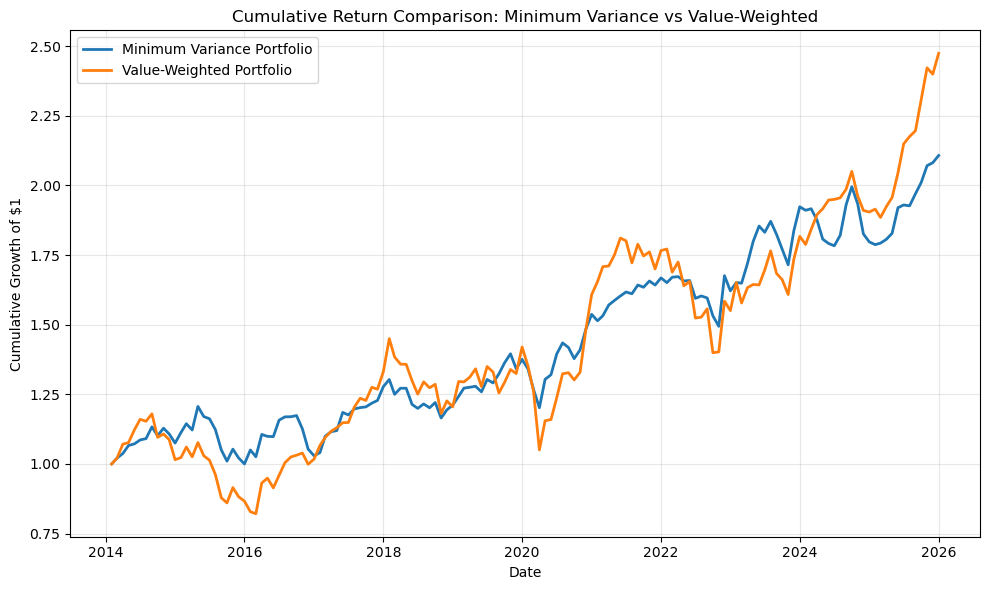


Files saved:
- Data_2026/Comparison_MV_vs_VW.xlsx
- Data_2026/Cumulative_Returns_MV_vs_VW.xlsx
- Data_2026/plots_mv_vs_vw/Cumulative_Return_Comparison_MV_vs_VW.png


In [47]:
print("Starting comparison with the value-weighted benchmark portfolio...")

import os
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 2.3 Comparison with the Value-Weighted Portfolio
# --------------------------------------------------------
# Benchmark formula:
#
#   R^(vw)_(t+1) = sum_i w_(i,t) * R_(i,t+1)
#
# where
#
#   w_(i,t) = Cap_(i,t) / sum_j Cap_(j,t)
#
# and Cap_(i,t) is the market capitalization of firm i
# at the end of month t.
#
# IMPORTANT:
# To avoid look-ahead bias, we must use market caps from month t
# to compute returns in month t+1. Therefore, market caps are lagged by 1 month.

# --------------------------------------------------------
# 1. Load Monthly Market Capitalization Data
# --------------------------------------------------------
mktcap_monthly = load_and_transpose('Data_2026/DS_MV_T_USD_M_2025.xlsx', is_monthly=True)

# Keep only firms from the EM universe
mktcap_em = mktcap_monthly[[isin for isin in valid_em_isins if isin in mktcap_monthly.columns]].copy()

# Align with return dates
mktcap_em = mktcap_em.reindex(returns_em.index)

# Lag market caps by one month to avoid look-ahead bias
mktcap_em_lagged = mktcap_em.shift(1)

# --------------------------------------------------------
# 2. Construct the Out-of-Sample Value-Weighted Portfolio
# --------------------------------------------------------
vw_out_of_sample_returns = []
vw_out_of_sample_dates = []

for holding_year in sorted(valid_investment_sets.keys()):

    # Restrict to the project evaluation period
    if holding_year < 2014 or holding_year > 2025:
        continue

    # Use the same yearly investment set as for the MV portfolio
    valid_isins = valid_investment_sets[holding_year]

    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    # Monthly returns during the holding year
    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31",
        valid_isins
    ].copy()

    # Lagged market caps used to form the benchmark weights
    holding_caps = mktcap_em_lagged.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31",
        valid_isins
    ].copy()

    # Keep consistency with your approved workflow
    holding_returns = holding_returns.fillna(0.0)
    holding_caps = holding_caps.fillna(0.0)

    for date, row_returns in holding_returns.iterrows():
        row_caps = holding_caps.loc[date].copy()

        # If no valid market cap information is available, store NaN
        if row_caps.sum() <= 0:
            R_vw = np.nan
        else:
            weights_vw = row_caps / row_caps.sum()
            R_vw = np.dot(weights_vw.values, row_returns.values)

        vw_out_of_sample_returns.append(R_vw)
        vw_out_of_sample_dates.append(date)

    print(f"Holding Year {holding_year}: value-weighted benchmark returns computed.")

# Build final benchmark return series
portfolio_vw_series = pd.Series(vw_out_of_sample_returns, index=vw_out_of_sample_dates)

# Restrict strictly to the evaluation sample
portfolio_vw_series = portfolio_vw_series.loc['2014-01-01':'2025-12-31']

print(f"\nFinal evaluated months for VW portfolio: {len(portfolio_vw_series)} (Expected: 144)")

# --------------------------------------------------------
# 3. Prepare the Minimum Variance Portfolio for Comparison
# --------------------------------------------------------
portfolio_mv_series = portfolio_oos_series.copy()
portfolio_mv_series = portfolio_mv_series.loc['2014-01-01':'2025-12-31']

# Convert both indices to monthly periods for perfect alignment
portfolio_mv_series.index = portfolio_mv_series.index.to_period('M')
portfolio_vw_series.index = portfolio_vw_series.index.to_period('M')

# --------------------------------------------------------
# 4. Load and Align the Risk-Free Rate
# --------------------------------------------------------
rf_df = pd.read_excel('Data_2026/Risk_Free_Rate_2025.xlsx', sheet_name='F-F_Research_Data_Factors')

date_col = rf_df.columns[0]
rate_col = rf_df.columns[1]

rf_df[date_col] = pd.to_datetime(rf_df[date_col].astype(str), format='%Y%m')
rf_df.set_index(date_col, inplace=True)

# Convert from percentage to decimal
rf_series = rf_df[rate_col] / 100.0
rf_series.index = rf_series.index.to_period('M')

rf_mv = rf_series.loc[portfolio_mv_series.index]
rf_vw = rf_series.loc[portfolio_vw_series.index]

mv_excess_returns = portfolio_mv_series - rf_mv
vw_excess_returns = portfolio_vw_series - rf_vw

# --------------------------------------------------------
# 5. Compute Summary Statistics
# --------------------------------------------------------
# Minimum Variance portfolio
mv_ann_avg_return = portfolio_mv_series.mean() * 12
mv_ann_volatility = portfolio_mv_series.std() * np.sqrt(12)
mv_ann_cum_return = (1 + portfolio_mv_series).prod() ** (12 / len(portfolio_mv_series)) - 1
mv_ann_excess_return = mv_excess_returns.mean() * 12
mv_sharp_ratio = mv_ann_excess_return / mv_ann_volatility if mv_ann_volatility != 0 else np.nan
mv_min_return = portfolio_mv_series.min()
mv_max_return = portfolio_mv_series.max()

# Value-Weighted portfolio
vw_ann_avg_return = portfolio_vw_series.mean() * 12
vw_ann_volatility = portfolio_vw_series.std() * np.sqrt(12)
vw_ann_cum_return = (1 + portfolio_vw_series).prod() ** (12 / len(portfolio_vw_series)) - 1
vw_ann_excess_return = vw_excess_returns.mean() * 12
vw_sharp_ratio = vw_ann_excess_return / vw_ann_volatility if vw_ann_volatility != 0 else np.nan
vw_min_return = portfolio_vw_series.min()
vw_max_return = portfolio_vw_series.max()

comparison_stats = pd.DataFrame({
    'Metric': [
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharp ratio',
        'Minimum monthly return',
        'Maximum monthly return'
    ],
    'Minimum Variance Portfolio': [
        mv_ann_avg_return,
        mv_ann_volatility,
        mv_ann_cum_return,
        mv_sharp_ratio,
        mv_min_return,
        mv_max_return
    ],
    'Value-Weighted Portfolio': [
        vw_ann_avg_return,
        vw_ann_volatility,
        vw_ann_cum_return,
        vw_sharp_ratio,
        vw_min_return,
        vw_max_return
    ]
})

print("\nSummary statistics comparison:")
display(comparison_stats)

# --------------------------------------------------------
# 6. Plot Cumulative Return Series
# --------------------------------------------------------
mv_plot = portfolio_mv_series.copy()
vw_plot = portfolio_vw_series.copy()

mv_plot.index = mv_plot.index.to_timestamp(how='end')
vw_plot.index = vw_plot.index.to_timestamp(how='end')

mv_cumulative = (1 + mv_plot).cumprod()
vw_cumulative = (1 + vw_plot).cumprod()

mv_cumulative = mv_cumulative / mv_cumulative.iloc[0]
vw_cumulative = vw_cumulative / vw_cumulative.iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(mv_cumulative.index, mv_cumulative.values, linewidth=2, label='Minimum Variance Portfolio')
plt.plot(vw_cumulative.index, vw_cumulative.values, linewidth=2, label='Value-Weighted Portfolio')
plt.title('Cumulative Return Comparison: Minimum Variance vs Value-Weighted')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 7. Export Results
# --------------------------------------------------------
output_dir = "Data_2026/plots_mv_vs_vw"
os.makedirs(output_dir, exist_ok=True)

comparison_stats.to_excel('Data_2026/Comparison_MV_vs_VW.xlsx', index=False)

comparison_returns = pd.DataFrame({
    'Minimum_Variance_Return': mv_plot,
    'Value_Weighted_Return': vw_plot,
    'Minimum_Variance_Cumulative': mv_cumulative,
    'Value_Weighted_Cumulative': vw_cumulative
})
comparison_returns.to_excel('Data_2026/Cumulative_Returns_MV_vs_VW.xlsx')

plt.figure(figsize=(10, 6))
plt.plot(mv_cumulative.index, mv_cumulative.values, linewidth=2, label='Minimum Variance Portfolio')
plt.plot(vw_cumulative.index, vw_cumulative.values, linewidth=2, label='Value-Weighted Portfolio')
plt.title('Cumulative Return Comparison: Minimum Variance vs Value-Weighted')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/Cumulative_Return_Comparison_MV_vs_VW.png", dpi=300, bbox_inches='tight')
plt.close()

print("\nFiles saved:")
print("- Data_2026/Comparison_MV_vs_VW.xlsx")
print("- Data_2026/Cumulative_Returns_MV_vs_VW.xlsx")
print(f"- {output_dir}/Cumulative_Return_Comparison_MV_vs_VW.png")

Starting Section 3.1 - Carbon Emissions Analysis...
Revenue loaded:    27 years, 701 firms
Market cap loaded: 27 years, 702 firms
Carbon intensity computed using Scope 1 + Scope 2.

=== Value-Weighted Portfolio Carbon Metrics ===


,Formation_Year,WACI_VW,CF_VW,N_Firms
Holding_Year,,,,
2014,2013,572.0070,463.6123,245
2015,2014,630.9786,582.8133,267
2016,2015,516.1690,464.8969,295
2017,2016,627.9708,707.5332,332
2018,2017,700.3170,662.7377,379
2019,2018,483.9453,589.3313,414
2020,2019,587.8497,690.2600,461
2021,2020,416.3204,672.9492,502
2022,2021,422.5717,587.9510,540



=== Top 10 Firms Driving WACI Up — Value-Weighted Portfolio ===
(Average contribution over the full sample 2014-2025)



,Company Name,ISIN,Years_Present,Avg_Weight,Avg_CI,Avg_WACI_Contribution
208,NTPC,INE733E01010,12,0.004187,16143.499234,69.008189
200,ULTRATECH CEMENT,INE481G01011,12,0.003323,9498.042757,31.441308
368,GAZPROM,RU0007661625,11,0.015874,1889.834354,23.446294
566,SASOL,ZAE000006896,12,0.004238,4433.738376,18.370662
297,IOI CORPORATION,MYL1961OO001,7,0.000948,16717.642475,11.810087
470,TAIWAN SEMICON.MNFG.,TW0002330008,12,0.047125,230.663490,10.632097
378,OC ROSNEFT,RU000A0J2Q06,11,0.014157,782.796316,9.677531
318,TENAGA NASIONAL,MYL5347OO009,12,0.003674,2849.488427,9.550386
135,RELIANCE INDUSTRIES,INE002A01018,12,0.019560,498.632305,9.427796
158,AMBUJA CEMENTS,INE079A01024,12,0.001378,6138.342270,8.807633


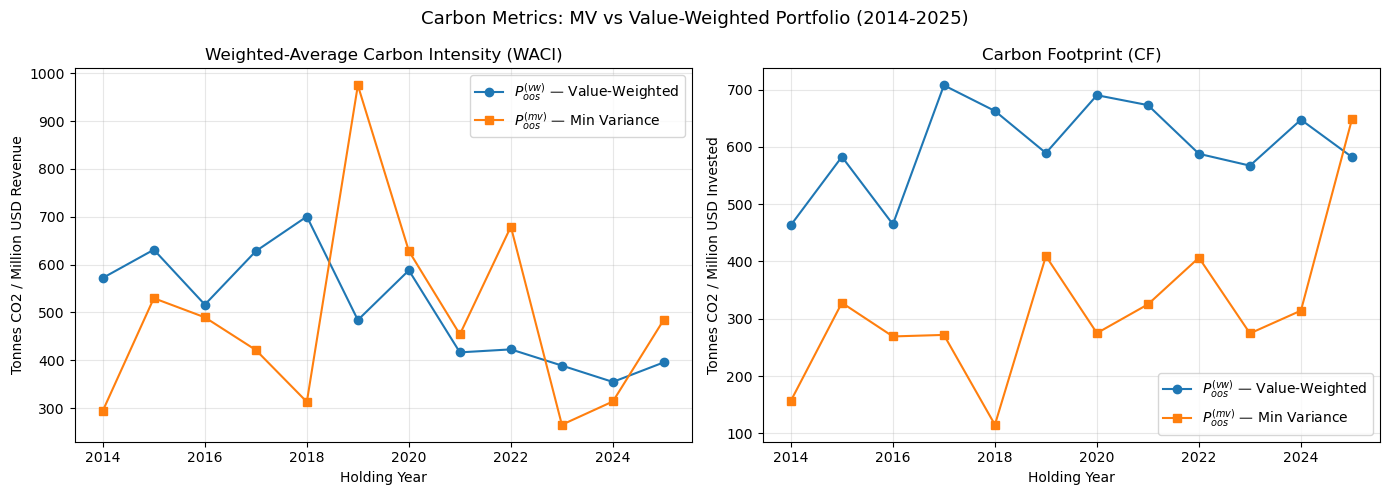


Section 3.1 completed. Files saved in: outputs/part_3_1


In [48]:
print("Starting Section 3.1 - Carbon Emissions Analysis...")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================================================
# 1) OUTPUT FOLDERS
# =========================================================
output_dir = "outputs/part_3_1"
plots_dir  = os.path.join(output_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

# =========================================================
# 2) STATIC FILE: COMPANY NAMES
# =========================================================
# static_df is already loaded from Part I
name_col = None
for c in static_df.columns:
    if "NAME" in str(c).upper():
        name_col = c
        break

isin_to_name = {}
if name_col is not None:
    isin_to_name = (
        static_df[["ISIN", name_col]]
        .drop_duplicates(subset=["ISIN"])
        .set_index("ISIN")[name_col]
        .to_dict()
    )

# =========================================================
# 3) LOAD ANNUAL REVENUE AND MARKET CAP
# =========================================================
# scope1_em and scope2_em are already loaded, cleaned,
# filtered to EM and forward-filled in Part I — reuse them directly.
#
# Only revenue and market cap need to be loaded here
# as they were not loaded in Part I.

rev_y = load_and_transpose("Data_2026/DS_REV_Y_2025.xlsx", is_monthly=False)
cap_y = load_and_transpose("Data_2026/DS_MV_T_USD_Y_2025.xlsx", is_monthly=False)

rev_y = rev_y[[i for i in valid_em_isins if i in rev_y.columns]].copy()
cap_y = cap_y[[i for i in valid_em_isins if i in cap_y.columns]].copy()

# Replace zero with NaN before ffill (zero revenue/cap = missing data)
rev_y = rev_y.replace(0.0, np.nan).sort_index().ffill()
cap_y = cap_y.replace(0.0, np.nan).sort_index().ffill()

rev_y.dropna(how="all", axis=1, inplace=True)
cap_y.dropna(how="all", axis=1, inplace=True)

print(f"Revenue loaded:    {rev_y.shape[0]} years, {rev_y.shape[1]} firms")
print(f"Market cap loaded: {cap_y.shape[0]} years, {cap_y.shape[1]} firms")

# =========================================================
# 4) BUILD EMISSIONS MATRIX AND CARBON INTENSITY
# =========================================================
# Group AC = Emerging Markets / Scope 1 + Scope 2
# Both scopes must be available — NaN if either is missing
# scope1_em and scope2_em already forward-filled from Part I
emissions_y  = scope1_em + scope2_em   # NaN + anything = NaN (correct)
carbon_label = "Scope 1 + Scope 2"

# Revenue in thousands USD -> divide by 1000 to get millions USD
rev_musd_y = rev_y / 1000.0
rev_musd_y = rev_musd_y.where(rev_musd_y > 0)  # keep only positive revenue

# Carbon Intensity: CI_{i,Y} = E_{i,Y} / Rev_{i,Y} (tonnes CO2 / million USD)
ci_y = emissions_y / rev_musd_y
ci_y = ci_y.replace([np.inf, -np.inf], np.nan)

print(f"Carbon intensity computed using {carbon_label}.")

# =========================================================
# 5) VALUE-WEIGHTED PORTFOLIO: WACI AND CF
# =========================================================
# WACI^(vw)_Y = sum_i w_{i,Y} * CI_{i,Y}
# CF^(vw)_Y   = (1/Cap_Y) * sum_i E_{i,Y}
#
# Investment set already guarantees carbon availability.
# Only additional filter: firms missing revenue (CI) or market cap.

vw_rows          = []
vw_contributions = {}

for holding_year in range(2014, 2026):
    formation_year = holding_year - 1

    if holding_year not in valid_investment_sets:
        continue
    if formation_year not in ci_y.index:
        continue
    if formation_year not in emissions_y.index:
        continue
    if formation_year not in cap_y.index:
        continue

    year_universe = valid_investment_sets[holding_year]

    # Filter: only firms with valid CI and valid market cap
    # (carbon already guaranteed by investment set from Part I)
    year_universe = [
        i for i in year_universe
        if i in ci_y.columns
        and i in emissions_y.columns
        and i in cap_y.columns
    ]

    if len(year_universe) == 0:
        continue

    temp = pd.DataFrame({
        "cap":       cap_y.loc[formation_year, year_universe],
        "ci":        ci_y.loc[formation_year, year_universe],
        "emissions": emissions_y.loc[formation_year, year_universe]
    }).dropna()   # drops firms missing CI (= missing revenue) or missing cap

    temp = temp[temp["cap"] > 0].copy()

    if len(temp) == 0:
        continue

    # VW weights: w_{i,Y} = Cap_{i,Y} / Cap_Y
    Cap_Y          = temp["cap"].sum()
    temp["weight"] = temp["cap"] / Cap_Y

    # WACI^(vw)_Y = sum_i w_{i,Y} * CI_{i,Y}
    temp["waci_contribution"] = temp["weight"] * temp["ci"]
    waci_vw_year = temp["waci_contribution"].sum()

    # CF^(vw)_Y = (1/Cap_Y) * sum_i E_{i,Y}
    cf_vw_year = temp["emissions"].sum() / Cap_Y

    # Store firm-level contributions for Top 10 analysis
    contrib_df         = temp.copy()
    contrib_df["ISIN"] = contrib_df.index
    contrib_df["Name"] = contrib_df["ISIN"].map(isin_to_name)
    contrib_df         = contrib_df.sort_values("waci_contribution", ascending=False)
    vw_contributions[holding_year] = contrib_df.copy()

    vw_rows.append({
        "Holding_Year":   holding_year,
        "Formation_Year": formation_year,
        "WACI_VW":        waci_vw_year,
        "CF_VW":          cf_vw_year,
        "N_Firms":        len(temp)
    })

vw_carbon_df = pd.DataFrame(vw_rows).set_index("Holding_Year")

# =========================================================
# EXPOSE AS DICTIONARIES FOR USE IN SECTIONS 3.2, 3.3, 3.4
# =========================================================
# cf_vw and waci_vw must be dictionaries {holding_year: value}
# so that later sections can do: if holding_year not in cf_vw
cf_vw   = vw_carbon_df["CF_VW"].to_dict()
waci_vw = vw_carbon_df["WACI_VW"].to_dict()

print("\n=== Value-Weighted Portfolio Carbon Metrics ===")
display(vw_carbon_df.round(4))

# =========================================================
# 6) TOP 10 FIRMS DRIVING WACI UP IN VW PORTFOLIO
# =========================================================
# Average contribution = total contribution over all years / 12
# Dividing by 12 (not years present) gives a fair comparison
# between firms present every year vs only some years

all_vw_contrib = []
for holding_year, df_year in vw_contributions.items():
    tmp                 = df_year.copy()
    tmp["Holding_Year"] = holding_year
    all_vw_contrib.append(tmp.reset_index(drop=True))

if len(all_vw_contrib) > 0:
    full_sample_vw = pd.concat(all_vw_contrib, ignore_index=True)

    top10_vw = (
        full_sample_vw
        .groupby("ISIN", as_index=False)
        .agg(
            Years_Present         = ("Holding_Year",      "nunique"),
            Avg_Weight            = ("weight",            "mean"),
            Avg_CI                = ("ci",                "mean"),
            Avg_WACI_Contribution = ("waci_contribution", lambda x: x.sum() / 12)
        )
        .sort_values("Avg_WACI_Contribution", ascending=False)
        .head(10)
    )

    top10_vw["Company Name"] = top10_vw["ISIN"].map(isin_to_name)
    top10_vw = top10_vw[[
        "Company Name", "ISIN", "Years_Present",
        "Avg_Weight", "Avg_CI", "Avg_WACI_Contribution"
    ]]

    print("\n=== Top 10 Firms Driving WACI Up — Value-Weighted Portfolio ===")
    print("(Average contribution over the full sample 2014-2025)\n")
    display(top10_vw.round(6))

# =========================================================
# 7) PLOTS
# =========================================================
# Compute WACI and CF for MV portfolio to add to the plots
# Using the same filter logic as VW above

waci_mv_plot = {}
cf_mv_plot   = {}

# Wealth path for MV (needed for CF formula)
mv_monthly = portfolio_mv_series.copy()
mv_monthly.index = mv_monthly.index.to_timestamp(how='end')

mv_annual_returns = {}
for year in range(2014, 2026):
    mv_annual_returns[year] = (1 + mv_monthly.loc[f"{year}-01-01":f"{year}-12-31"]).prod() - 1

portfolio_value_mv = {2013: 1.0}  # 1.0 million USD
for year in range(2014, 2026):
    portfolio_value_mv[year] = portfolio_value_mv[year - 1] * (1 + mv_annual_returns[year])

for holding_year in range(2014, 2026):
    formation_year = holding_year - 1

    if holding_year not in optimal_weights_mv:
        continue

    alpha_Y     = optimal_weights_mv[holding_year]
    valid_isins = alpha_Y.index.tolist()

    # Same filter as VW: only exclude firms missing CI or market cap
    common = [
        i for i in valid_isins
        if i in ci_y.columns
        and i in emissions_y.columns
        and i in cap_y.columns
    ]

    if len(common) == 0:
        continue

    temp = pd.DataFrame({
        "alpha":     alpha_Y[common],
        "ci":        ci_y.loc[formation_year, common],
        "emissions": emissions_y.loc[formation_year, common],
        "cap":       cap_y.loc[formation_year, common]
    }).dropna()

    temp = temp[temp["cap"] > 0].copy()

    if len(temp) == 0:
        continue

    # Renormalize weights after exclusions
    temp["alpha"] = temp["alpha"] / temp["alpha"].sum()

    V_Y = portfolio_value_mv[formation_year]  # millions USD

    # WACI^(mv)_Y = sum_i alpha_{i,Y} * CI_{i,Y}
    waci_mv_plot[holding_year] = np.dot(temp["alpha"].values, temp["ci"].values)

    # CF^(mv)_Y = sum_i alpha_{i,Y} * (E_{i,Y} / Cap_{i,Y})
    o_iY = (temp["alpha"].values * V_Y) / temp["cap"].values
    cf_mv_plot[holding_year] = np.sum(o_iY * temp["emissions"].values) / V_Y

# Also expose MV carbon metrics as dictionaries for 3.2, 3.3, 3.4
cf_mv   = cf_mv_plot    # {holding_year: CF value}   used as CF target in 3.2
waci_mv = waci_mv_plot  # {holding_year: WACI value} used in plots in 3.2, 3.4

# --- Plot ---
years_vw = sorted(vw_carbon_df.index.tolist())
years_mv = sorted(waci_mv_plot.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(years_vw, [vw_carbon_df.loc[y, "WACI_VW"] for y in years_vw],
             marker="o", label="$P^{(vw)}_{oos}$ — Value-Weighted")
axes[0].plot(years_mv, [waci_mv_plot[y] for y in years_mv],
             marker="s", label="$P^{(mv)}_{oos}$ — Min Variance")
axes[0].set_title("Weighted-Average Carbon Intensity (WACI)")
axes[0].set_xlabel("Holding Year")
axes[0].set_ylabel("Tonnes CO2 / Million USD Revenue")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(years_vw, [vw_carbon_df.loc[y, "CF_VW"] for y in years_vw],
             marker="o", label="$P^{(vw)}_{oos}$ — Value-Weighted")
axes[1].plot(years_mv, [cf_mv_plot[y] for y in years_mv],
             marker="s", label="$P^{(mv)}_{oos}$ — Min Variance")
axes[1].set_title("Carbon Footprint (CF)")
axes[1].set_xlabel("Holding Year")
axes[1].set_ylabel("Tonnes CO2 / Million USD Invested")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Carbon Metrics: MV vs Value-Weighted Portfolio (2014-2025)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "carbon_metrics_mv_vs_vw.png"), dpi=300)
plt.show()

# =========================================================
# 8) SAVE OUTPUTS
# =========================================================
vw_carbon_df.to_excel(os.path.join(output_dir, "value_weighted_carbon_metrics.xlsx"))

if len(all_vw_contrib) > 0:
    top10_vw.to_excel(
        os.path.join(output_dir, "top10_waci_drivers_vw.xlsx"),
        index=False
    )

with pd.ExcelWriter(os.path.join(output_dir, "vw_yearly_waci_contributions.xlsx")) as writer:
    for holding_year, df in vw_contributions.items():
        df.reset_index(drop=True).to_excel(
            writer, sheet_name=str(holding_year)[:31], index=False
        )

print(f"\nSection 3.1 completed. Files saved in: {output_dir}")

Starting Section 3.2: Long-only portfolio with a carbon footprint objective...

P^(mv)_oos(0.5): 144 months (expected 144)

--- Summary Statistics Comparison ---


,Metric,P^(mv)_oos,P^(mv)_oos(0.5)
0,Annualized Average Return,0.0651,0.0620
1,Annualized Volatility,0.1091,0.1077
2,Annualized Cumulative Return,0.0609,0.0578
3,Sharpe Ratio,0.4366,0.4133
4,Minimum Monthly Return,-0.0646,-0.0634
5,Maximum Monthly Return,0.1216,0.1191



--- Carbon Metrics: Baseline MV vs MV (50% Reduction) ---


,WACI_MV,WACI_MV_05,CF_MV,CF_MV_05
Year,,,,
2014,294.28,187.78,156.90,78.45
2015,529.56,170.42,327.89,163.94
2016,489.56,209.34,269.21,134.60
2017,421.26,184.41,271.87,135.93
2018,312.82,98.86,115.06,57.53
2019,974.69,552.80,409.48,204.74
2020,628.22,274.11,275.01,137.51
2021,453.94,325.72,325.21,162.60
2022,679.13,529.18,406.65,203.33


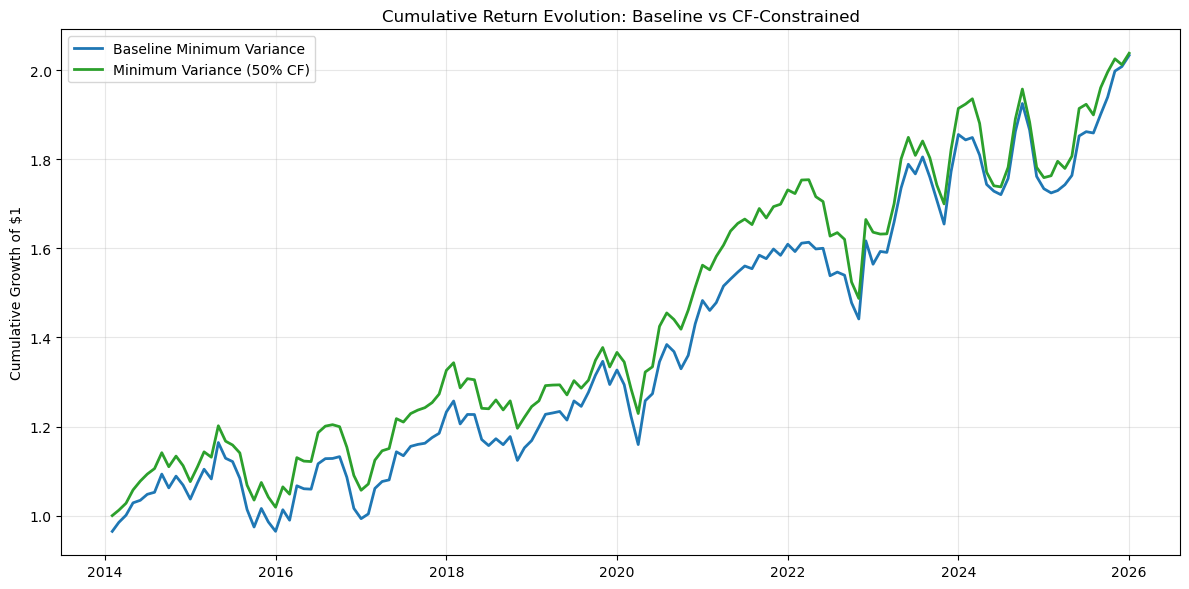

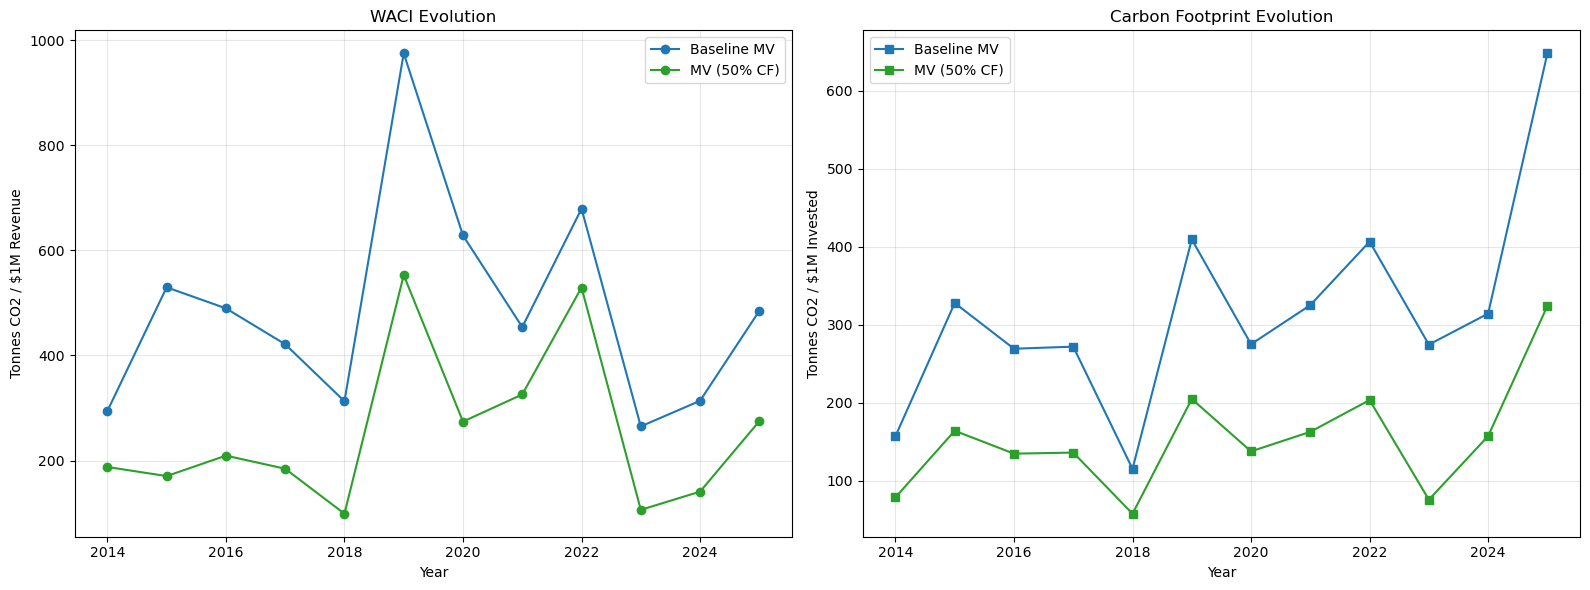


--- EXCLUDED FIRMS: Top 5 firms completely dropped from the portfolio ---


,ISIN,Name,Years_Excluded
47,TW0003045001,TAIWAN MOBILE,6
27,MYL4707OO005,NESTLE (MALAYSIA),4
32,PEP702101002,ENGIE ENERGIA PERU,4
28,MYL5347OO009,TENAGA NASIONAL,3
50,TW0009917005,TAIWAN SECOM,3



--- HISTORICAL AVERAGE: Top 5 Under-Weighted Firms ---


,Name,Baseline_MV,MV_05,Shift
TW0003045001,TAIWAN MOBILE,0.0602,0.0237,-0.0365
PEP702101002,ENGIE ENERGIA PERU,0.0127,0.0015,-0.0112
TW0002912003,PRESIDENT CHAIN STORE,0.0368,0.0260,-0.0107
TW0004904008,FAR EASTONE TELECOM.,0.0418,0.0317,-0.0101
TH1074010006,PTT GLOBAL CHEMICAL,0.0404,0.0307,-0.0098



--- HISTORICAL AVERAGE: Top 5 Over-Weighted Firms ---


,Name,Baseline_MV,MV_05,Shift
TW0002412004,CHUNGHWA TELECOM,0.1693,0.2736,0.1044
ID1000118201,BANK RAKYAT INDONESIA,0.0386,0.0640,0.0254
TW0009917005,TAIWAN SECOM,0.0363,0.0416,0.0053
MYL4065OO008,PPB GROUP,0.0036,0.0081,0.0045
EGS60081C014,QATAR NATIONAL BANK,0.0102,0.0146,0.0044



Section 3.2 completed.


In [53]:
print("Starting Section 3.2: Long-only portfolio with a carbon footprint objective...")

# =========================================================================
# 1. Setup & Data Initialization
# =========================================================================
base_output_dir = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
analysis_output_dir = os.path.join(base_output_dir, "composition_analysis")
os.makedirs(plots_output_dir, exist_ok=True)
os.makedirs(analysis_output_dir, exist_ok=True)

# Static names mapping
isin_to_name = {}
name_col = None
for c in static_df.columns:
    if "NAME" in str(c).upper():
        name_col = c
        break
if name_col is not None:
    isin_to_name = (
        static_df[["ISIN", name_col]]
        .drop_duplicates(subset=["ISIN"])
        .set_index("ISIN")[name_col]
        .to_dict()
    )

# Dictionaries to store out-of-sample data
optimal_weights_mv_05 = {}
returns_mv_05 = []
dates_mv_05 = []
yearly_shifts = []

# =========================================================================
# 2. Constrained Optimization Loop (Holding Years 2014-2025)
# =========================================================================
for holding_year in range(2014, 2026):
    data_year = holding_year - 1

    if holding_year not in sigma_estimates or holding_year not in optimal_weights_mv:
        continue

    # FIX 1: check cf_mv is available for this year
    if holding_year not in cf_mv:
        continue

    w_mv_baseline_all = optimal_weights_mv[holding_year]
    Sigma_Y_all = sigma_estimates[holding_year]
    isins = w_mv_baseline_all.index.tolist()

    # FIX 2: use correct variable names emissions_y and ci_y
    E_t   = emissions_y.loc[data_year, isins] if data_year in emissions_y.index else pd.Series(np.nan, index=isins)
    CI_t  = ci_y.loc[data_year, isins]        if data_year in ci_y.index        else pd.Series(np.nan, index=isins)
    Cap_t = cap_y.loc[data_year, isins]       if data_year in cap_y.index       else pd.Series(np.nan, index=isins)

    # Restrict to valid firms
    valid_mask  = CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins = CI_t[valid_mask].index.tolist()
    n_assets    = len(valid_isins)

    if n_assets == 0:
        continue

    Sigma_sub = Sigma_Y_all.loc[valid_isins, valid_isins].to_numpy()

    w_mv_base = w_mv_baseline_all[valid_isins].to_numpy()
    w_mv_base = w_mv_base / np.sum(w_mv_base)

    c_vector = (E_t[valid_isins] / Cap_t[valid_isins]).to_numpy()

    # FIX 3: use cf_mv from Section 3.1 instead of recomputing
    CF_target_Y = 0.5 * cf_mv[holding_year]

    # ---------------------------------------------------------------------
    # Optimization Setup
    # ---------------------------------------------------------------------
    def portfolio_variance(w, cov_matrix):
        return (w.T @ cov_matrix @ w) * 10000

    constraints = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq', 'fun': lambda w: (CF_target_Y - np.dot(w, c_vector)) / max(cf_mv[holding_year], 1e-6)}
    ]
    bounds   = tuple((0.0, 1.0) for _ in range(n_assets))
    initial_w = np.ones(n_assets) / n_assets

    res = minimize(portfolio_variance, initial_w, args=(Sigma_sub,),
                   method='SLSQP', bounds=bounds, constraints=constraints)

    # FIX 4: skip year instead of using fallback
    if not res.success:
        print(f"  Year {holding_year}: optimization FAILED — {res.message}")
        continue

    w_opt = np.round(res.x, 6)
    w_opt = w_opt / np.sum(w_opt)

    optimal_weights_mv_05[holding_year] = pd.Series(w_opt, index=valid_isins)

    # Store year-by-year shifts
    year_shift_df = pd.DataFrame({
        'Year':           holding_year,
        'ISIN':           valid_isins,
        'Name':           [isin_to_name.get(i, i) for i in valid_isins],
        'Weight_MV':      w_mv_base,
        'Weight_MV_CF50': w_opt,
        'Delta_Weight':   w_opt - w_mv_base
    })
    yearly_shifts.append(year_shift_df)

    # Ex-Post Performance Tracking
    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31", valid_isins
    ].fillna(0.0)

    current_w = w_opt.copy()

    for date, row in holding_returns.iterrows():
        R_tk = row.values
        R_p  = np.dot(current_w, R_tk)

        returns_mv_05.append(R_p)
        dates_mv_05.append(date)

        current_w = current_w * (1 + R_tk) / (1 + R_p)
        current_w = current_w / np.sum(current_w)

portfolio_mv_05_series       = pd.Series(returns_mv_05, index=dates_mv_05).loc['2014-01-01':'2025-12-31']
portfolio_mv_05_series.index = portfolio_mv_05_series.index.to_period('M')

print(f"\nP^(mv)_oos(0.5): {len(portfolio_mv_05_series)} months (expected 144)")

# Compile and export Year-by-Year Table
df_yearly_shifts = pd.concat(yearly_shifts, ignore_index=True)
df_yearly_shifts.to_excel(os.path.join(analysis_output_dir, "Year_by_Year_Composition_Shifts.xlsx"), index=False)

# =========================================================================
# 3. Portfolio Characteristics & Comparison
# =========================================================================
rf_mv_05             = rf_series.loc[portfolio_mv_05_series.index]
mv_05_excess_returns = portfolio_mv_05_series - rf_mv_05

ann_ret_05     = portfolio_mv_05_series.mean() * 12
ann_vol_05     = portfolio_mv_05_series.std()  * np.sqrt(12)
ann_cum_05     = (1 + portfolio_mv_05_series).prod() ** (12 / len(portfolio_mv_05_series)) - 1
sharpe_ratio_05 = (mv_05_excess_returns.mean() * 12) / ann_vol_05 if ann_vol_05 != 0 else np.nan
min_ret_05     = portfolio_mv_05_series.min()
max_ret_05     = portfolio_mv_05_series.max()

# Build comparison table from scratch
rf_mv_aligned = rf_series.loc[portfolio_mv_series.index]
ann_ret_mv    = portfolio_mv_series.mean() * 12
ann_vol_mv    = portfolio_mv_series.std()  * np.sqrt(12)
ann_cum_mv    = (1 + portfolio_mv_series).prod() ** (12 / len(portfolio_mv_series)) - 1
sharpe_mv     = ((portfolio_mv_series - rf_mv_aligned).mean() * 12) / ann_vol_mv
min_mv        = portfolio_mv_series.min()
max_mv        = portfolio_mv_series.max()

comparison_stats = pd.DataFrame({
    'Metric': [
        'Annualized Average Return',
        'Annualized Volatility',
        'Annualized Cumulative Return',
        'Sharpe Ratio',
        'Minimum Monthly Return',
        'Maximum Monthly Return'
    ],
    'P^(mv)_oos': [
        ann_ret_mv, ann_vol_mv, ann_cum_mv, sharpe_mv, min_mv, max_mv
    ],
    'P^(mv)_oos(0.5)': [
        ann_ret_05, ann_vol_05, ann_cum_05, sharpe_ratio_05, min_ret_05, max_ret_05
    ]
})

print("\n--- Summary Statistics Comparison ---")
display(comparison_stats.round(4))

# =========================================================================
# 4. Ex-Post Carbon Metrics Evolution
# =========================================================================
# Wealth path using timestamp conversion (safe on Period index)
mv_05_monthly       = portfolio_mv_05_series.copy()
mv_05_monthly.index = mv_05_monthly.index.to_timestamp(how='end')

annual_ret_mv_05 = {}
for year in range(2014, 2026):
    annual_ret_mv_05[year] = (
        (1 + mv_05_monthly.loc[f"{year}-01-01":f"{year}-12-31"]).prod() - 1
    )

wealth_mv_05 = {2013: 1.0}
for year in range(2014, 2026):
    wealth_mv_05[year] = wealth_mv_05[year - 1] * (1 + annual_ret_mv_05[year])

metrics_05 = []

for holding_year in range(2014, 2026):
    data_year = holding_year - 1

    if holding_year not in optimal_weights_mv_05:
        continue

    w_05    = optimal_weights_mv_05[holding_year]
    isins   = w_05.index.tolist()

    # FIX 2 (again): correct variable names in metrics loop
    E_t   = emissions_y.loc[data_year, isins] if data_year in emissions_y.index else pd.Series(np.nan, index=isins)
    CI_t  = ci_y.loc[data_year, isins]        if data_year in ci_y.index        else pd.Series(np.nan, index=isins)
    Cap_t = cap_y.loc[data_year, isins]       if data_year in cap_y.index       else pd.Series(np.nan, index=isins)

    WACI_05 = np.sum(w_05 * CI_t)
    V_05    = wealth_mv_05[data_year]
    o_i_05  = (w_05 * V_05) / Cap_t
    CF_05   = (1 / V_05) * np.sum(o_i_05 * E_t)

    metrics_05.append({'Year': holding_year, 'WACI_MV_05': WACI_05, 'CF_MV_05': CF_05})

df_metrics_05 = pd.DataFrame(metrics_05).set_index('Year')

# Build df_all_metrics from scratch
metrics_mv = []
for holding_year in range(2014, 2026):
    if holding_year not in waci_mv or holding_year not in cf_mv:
        continue
    metrics_mv.append({
        'Year':    holding_year,
        'WACI_MV': waci_mv[holding_year],
        'CF_MV':   cf_mv[holding_year]
    })
df_metrics_mv  = pd.DataFrame(metrics_mv).set_index('Year')
df_all_metrics = df_metrics_mv.join(df_metrics_05)

print("\n--- Carbon Metrics: Baseline MV vs MV (50% Reduction) ---")
display(df_all_metrics[['WACI_MV', 'WACI_MV_05', 'CF_MV', 'CF_MV_05']].round(2))

# =========================================================================
# 5. Visualizations: Cumulative Returns & Environmental Impact
# =========================================================================
mv_plot         = portfolio_mv_series.copy()
mv_05_plot      = portfolio_mv_05_series.copy()
mv_plot.index   = mv_plot.index.to_timestamp(how='end')
mv_05_plot.index = mv_05_plot.index.to_timestamp(how='end')

mv_cumulative   = (1 + mv_plot).cumprod()
mv_05_cumulative = (1 + mv_05_plot).cumprod()
mv_05_cumulative = mv_05_cumulative / mv_05_cumulative.iloc[0]

# Plot 1: Cumulative Returns
plt.figure(figsize=(12, 6))
plt.plot(mv_cumulative.index,    mv_cumulative.values,    linewidth=2, label='Baseline Minimum Variance',  color='tab:blue')
plt.plot(mv_05_cumulative.index, mv_05_cumulative.values, linewidth=2, label='Minimum Variance (50% CF)', color='tab:green')
plt.title('Cumulative Return Evolution: Baseline vs CF-Constrained')
plt.ylabel('Cumulative Growth of $1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_2_CumulativeReturn.png"), dpi=300)
plt.show()

# Plot 2: Carbon Metrics
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

df_all_metrics[['WACI_MV', 'WACI_MV_05']].plot(ax=ax[0], marker='o', color=['tab:blue', 'tab:green'])
ax[0].set_title('WACI Evolution')
ax[0].set_ylabel('Tonnes CO2 / $1M Revenue')
ax[0].grid(True, alpha=0.3)
ax[0].legend(['Baseline MV', 'MV (50% CF)'])

df_all_metrics[['CF_MV', 'CF_MV_05']].plot(ax=ax[1], marker='s', color=['tab:blue', 'tab:green'])
ax[1].set_title('Carbon Footprint Evolution')
ax[1].set_ylabel('Tonnes CO2 / $1M Invested')
ax[1].grid(True, alpha=0.3)
ax[1].legend(['Baseline MV', 'MV (50% CF)'])

plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_2_CarbonEvolution.png"), dpi=300)
plt.show()

# =========================================================================
# 6. Composition Changes (Exclusions, Over/Under-weights)
# =========================================================================
# 6.1 Excluded Firms Analysis
excluded_mask    = (df_yearly_shifts['Weight_MV'] > 0.001) & (df_yearly_shifts['Weight_MV_CF50'] < 0.00001)
excluded_firms   = (
    df_yearly_shifts[excluded_mask]
    .groupby(['ISIN', 'Name'])
    .size()
    .reset_index(name='Years_Excluded')
    .sort_values('Years_Excluded', ascending=False)
    .head(5)
)

print("\n--- EXCLUDED FIRMS: Top 5 firms completely dropped from the portfolio ---")
display(excluded_firms)

# 6.2 Historical Average Allocation Shifts
num_years      = 12
avg_weights_base = pd.DataFrame(optimal_weights_mv).fillna(0).sum(axis=1)    / num_years
avg_weights_05   = pd.DataFrame(optimal_weights_mv_05).fillna(0).sum(axis=1) / num_years

weight_diff = pd.DataFrame({
    'Baseline_MV': avg_weights_base,
    'MV_05':       avg_weights_05,
    'Shift':       avg_weights_05 - avg_weights_base
}).fillna(0)
weight_diff['Name'] = [isin_to_name.get(i, i) for i in weight_diff.index]

top_underweighted = weight_diff.sort_values('Shift').head(5)
top_overweighted  = weight_diff.sort_values('Shift', ascending=False).head(5)

print("\n--- HISTORICAL AVERAGE: Top 5 Under-Weighted Firms ---")
display(top_underweighted[['Name', 'Baseline_MV', 'MV_05', 'Shift']].round(4))

print("\n--- HISTORICAL AVERAGE: Top 5 Over-Weighted Firms ---")
display(top_overweighted[['Name', 'Baseline_MV', 'MV_05', 'Shift']].round(4))

print("\nSection 3.2 completed.")